In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
500,6.07,24.0,1
39,7.25,17.0,0
517,6.37,38.0,1
274,7.13,4.0,1
118,6.90,54.0,0


In [4]:
print("Mean value of cgpa",df['cgpa'].mean())
print("sd of cgpa",df['cgpa'].std())
print("max value of cgpa",df['cgpa'].max())
print("Min value of cgpa",df['cgpa'].min())

Mean value of cgpa 6.96124
sd of cgpa 0.6158978751323896
max value of cgpa 9.12
Min value of cgpa 4.89


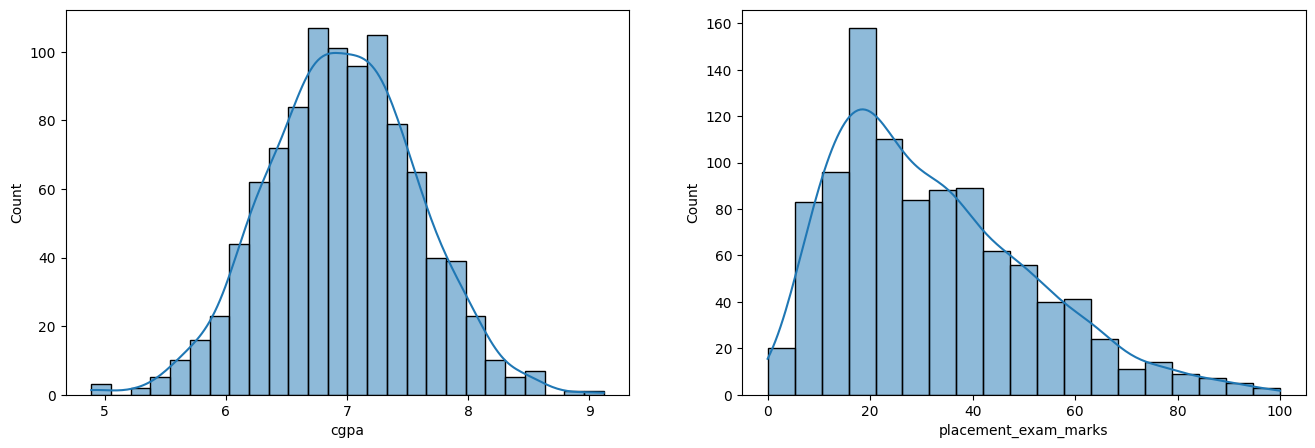

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.show()

#use only for normally distributed curves(not skewed ones)

In [6]:
print("highest allowed vlaue: ",df['cgpa'].mean()+(3*df['cgpa'].std()))
print("lowest allowed vlaue: ",df['cgpa'].mean()-(3*df['cgpa'].std()))

highest allowed vlaue:  8.808933625397168
lowest allowed vlaue:  5.113546374602832


In [7]:
#Finding Outliers
df[(df['cgpa']<5.11) | (df['cgpa']>8.8)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Trimming

In [8]:
new_df=df[(df['cgpa']>5.11) & (df['cgpa']<8.8)]

In [9]:
new_df.shape

(995, 3)

In [10]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [14]:
# Approch 2
df['z-score']=(df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()

In [15]:
df.head(5)

,cgpa,placement_exam_marks,placed,z-score
0,7.19,26.0,1,0.372949
1,7.46,38.0,1,0.813630
2,7.54,40.0,1,0.944202
3,6.42,8.0,1,-0.883807
4,7.23,17.0,0,0.438235


In [20]:
df[(df['z-score']>3) | (df['z-score']<-3)]

,cgpa,placement_exam_marks,placed,z-score
485,5.113546,44.0,1,-3.016137
995,8.808934,44.0,1,3.015293
996,8.808934,65.0,1,3.015293
997,5.113546,34.0,0,-3.016137
999,5.113546,10.0,1,-3.016137


In [23]:
# Trimming 
new_df = df[(df['z-score'] < 3) & (df['z-score'] > -3)]
new_df

,cgpa,placement_exam_marks,placed,z-score
0,7.19,26.0,1,0.372949
1,7.46,38.0,1,0.813630
2,7.54,40.0,1,0.944202
3,6.42,8.0,1,-0.883807
4,7.23,17.0,0,0.438235
...,...,...,...,...
991,7.04,57.0,0,0.128126
992,6.26,12.0,0,-1.144952
993,6.73,21.0,1,-0.377841
994,6.48,63.0,0,-0.785878


## Capping

In [24]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [25]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [26]:
df.shape

(1000, 4)